In [2]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network


## Loading the Data

In [3]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [4]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [5]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

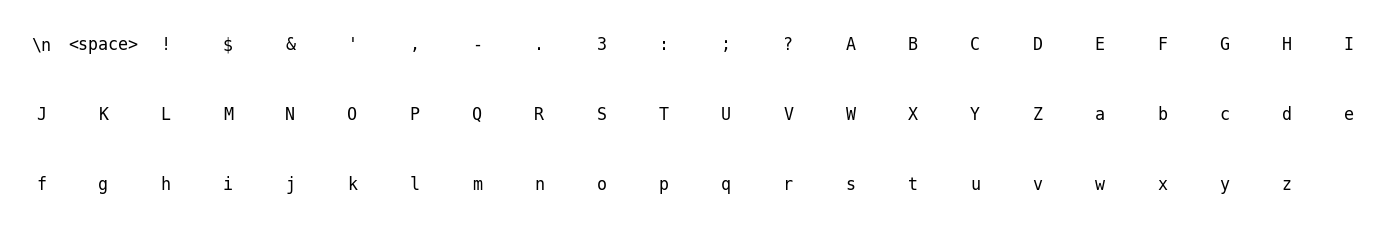

In [6]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [8]:
embedding_dim = 64
hidden_size = 128

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Softmax", "input_size": hidden_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: RecurrentLayer
  Weights Shape: (64, 128) | State Weights Shape: (128, 128) | Biases Shape: (128,)
  Parameters: 24,704

Layer 3: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 37,249


c:\Users\DANIELPEDERZINI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training the Model

In [9]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [10]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [11]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [12]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [13]:
sequence_length = 64
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.1
min_learning_rate = 0.001
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 10

In [14]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.1, 'train_perplexity': 13.672434115645649, 'test_perplexity': 9.862333372765862}
{'epoch': 50, 'learning_rate': 0.09767247740510235, 'train_perplexity': 5.3087087928788685, 'test_perplexity': 5.634658751873348}
{'epoch': 100, 'learning_rate': 0.09072836113943815, 'train_perplexity': 4.944987980985947, 'test_perplexity': 5.443436881802283}
{'epoch': 150, 'learning_rate': 0.07984641259797244, 'train_perplexity': 4.776702785262298, 'test_perplexity': 5.337996734840847}
{'epoch': 200, 'learning_rate': 0.06609183272293759, 'train_perplexity': 4.658528683129282, 'test_perplexity': 5.305837072172223}
{'epoch': 250, 'learning_rate': 0.050811015626295176, 'train_perplexity': 4.569117532690224, 'test_perplexity': 5.2671542902922965}
{'epoch': 300, 'learning_rate': 0.0354997541531777, 'train_perplexity': 4.499321024981435, 'test_perplexity': 5.229214402824038}
{'epoch': 350, 'learning_rate': 0.021656821256405494, 'train_perplexity': 4.442572430293333, 'test_perplex

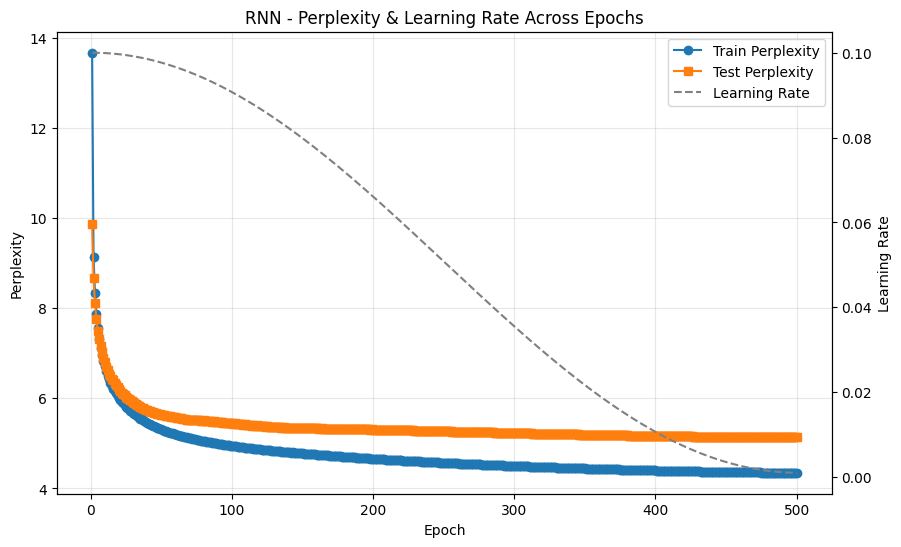

In [15]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Learning Rate Across Epochs")
plt.show()

In [17]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [18]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.9, print_during=True)

DANIELA:
Is the is if is some him: and fit
foul with in: mest the my life's propell;
And doth in; sir,
And good elbow send usegn,
I ready his an me, that men to thee the deadou mine
nive them know quest will was thy break thy disconfied me the grace I stible consent thou good
soothly presence how are impediends Groult of hear ma.

LUCIO:
Not made,
Which office for the peace have we shall I have both:
This butcher thy thus I hames of cry, and a fearful nothin-cany strutward,
With upon him! her, them grieve?

AbEd:
There queen friends you are thee, the make my out weesit,
And pitsuey; what is otrug.

LADe
LAUTHAS:
Would Aumerdows see, and, all fick'd the queen master.

Luen?
His, E thead all interble shood him. He good
mised.

Lord and to think there: and and battent oftinon in you too than to be tooth not cur brother send the high powers this triug to dringed you I words thy have frient is I must:
I would words.
Faint beE
Yet o' the shaptings all fetch which more I content and fliege, t

In [20]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIELA:
I thing with the cousin, and be in up princed and news?

LADY ANNE:
I things be by thee us the lay be you.

MARCIUS:
I say, for a can men lies them and we our faited of the can most well, will hath your arms him possench and are he grace I duty.

LADY ANNE:
Why, that is my sood death,
Is to slood at your the say, many the father spend of his may well-be comest against the can may be bite good his slow of this man his arms this in of Prailt his doom in the words body.

Second can from the power fly go nothing:
And thing not of courts on your child
In the drows, with me,
I dakently in a servous wive the senses you good make sleasure you doom the murderer:
Sir, there's the grace here, would I till let it very not you fir be this desoldier, live: that make old not rest can death:
So love,
And shall not in the way breathe.

First present the tell give our hand.

MENENIUS:
Do I see he shall you arms.

KING EDWARD IV:
For for your most me in thy children,
Grem becomes no worser of th

In [23]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.5, print_during=True)

DANIELA:
I not not the hands some and with the hath you good fair my death!

Offices me sider the may so this daughter the villain, and and the will for the say, and comes you trumpet the shall make the duke, and of the be the word, I would here what the manst to see to the for the will good breather sit?

Romany the will for his presence the arms with the since thou art the lifer the of the hath a prouds bear the printern the will are for me to the constring as make the bloody warrioun encoural it the trium, and he should be them heart,
Give of for ence the brother: and the life the since all the pity his man the pray when the encounte to my lords the son that the have canst the have no love bold,
And then the shall not my cursed did and and of the see and be and stand to the love the extrue way his more the serven that the uncle the should have make his be the shall the have from the sent a should is the true is the love my father they the grace to my son the true have with it the pa

In [24]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.3, print_during=True)

DANIELA:
I will be to the serven the trial the word and the see the shall married be me that the tributes the shall and the shall me with the bear his more in the father your shall be my virtue a speak the man his son, with the fear the hast the shall to the matter to the service of the prove my son that with the truth the will heart the son and to the may we have say to the see the shall be with of the say the fair the shall be the see to the truth the man the rest of his stand a grace.

MENENIUS:
What the prove a son the shall see the shall so love the sentence the thing to the shall be the maiden he have will and he father the see the shall be shall stand and for the serve the should heaven the prove the see and have the princes with the fair the grace the have the see the see the cannot the see the see the should see a see the since to the father the shall be be the have thou art the may the shall for me as the see the man the have be and with the should here and the speak the have